# Treinamento com otimização de parâmetros e hiperparâmetros do modelo. 
- Nessa rotina são definidos as variáveis de modelo e processo para se procurar por um ponto de desempenho ótimo. 
- Foi definido fixamente o fator 10_000 para com a seleção de features apó a vetorização dos textos. Portanto o K de seleção não é um parâmetro variavel nesse procedimento.
- Define-se um "Fator de undersampling" = 1/ratio = 20 para o Random Undersampling.
    - Utilizar esse valor é conveniente conforme visto no notebook 5, e reduz pela metade o desbalanceamento envolvido (que ainda será alto).
    - A ordem entre a feature selection e udersampling também foi definida com os estudos dos notebooks 5 e 6. Optou-se por primeiro selecionar as features e depois samplear devido a uma menor flutuação dos resultados observados.
- Os outros parâmetros, os de otimização, são característicos e próprios para cada modelo do estudo.

- O tipo de otimização utilizado é a Otimização Bayesiana, por meio do gp_minimize (métricas que se quer aumentar é o mesmo que minimizar o negativo delas)
- uma pipeline das transformações é realizada para facilitar a aplicação das transformaçoes.

- As validaçoes cruzadas foram feitas em laços manuais a fim de se evitar a ocorrência de vazamento entre conjuntos de treino e validação. 
    - Pipelines típicas do sklearn não previnem isso, e o vazamento de dados na validação cruzada entre os folds de treino e validação é um dos erros mais comuns cometidos.
    - A biblioteca "imbalanced learn" possui ferramentas propícias para evitar esses vazamentos, contudo, aqui preferiu-se realizar o procedimento manual, até porque esse tipo de exercício é uma excelente forma de reforço no aprendizado.

# Métricas de otimização
- Realiza-se a otimização sobre a métrica "AUPRC" - Area Under the Precision–Recall Curve (área sob a curva Precisão×Recall).
- Em dados desbalanceados, ela mede quão bem o modelo recupera a classe de interesse (positiva) com poucas falsas detecções.
    - métrica contínua, independe de threshold, e é conveniente no contexto de desbalanceamento.

# A título de curiosidade
- Utilizou-se uma técnica de otimização de treshold, com fit logicamente no conjunto de treino, e aplicou-se no conjunto de teste.
    - Isso se mostrou uma abordagem interessante para alterar a métrica e o thresold de negócio para diferentes contextos.

#### **Obs**: No notebook 08 esses modelos com otimização de thr serão uteis.

# Import bibs

In [1]:
from skopt.space import Real, Integer, Categorical
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from joblib import dump, load
import joblib
from functools import partial
from pathlib import Path

import pandas as pd
import numpy as np
from collections import defaultdict
import os
import re
import json
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, average_precision_score,
    f1_score, balanced_accuracy_score,
    matthews_corrcoef, roc_auc_score
)
from imblearn.metrics import geometric_mean_score

from skopt import gp_minimize
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*", category=UserWarning)

# Funções para Otimização:

In [2]:
# Otimização de thr
def get_opt_cv_thr(df, fold_col, text_col, label_col, model_name, params, get_pipeline, partial_metric):
    """
    Executa validação cruzada para encontrar o threshold ótimo que maximiza uma métrica.

    Args:
        df (pd.DataFrame): DataFrame completo de treino.
        fold_col (str): Nome da coluna com a definição dos folds.
        text_col (str): Nome da coluna de texto para features.
        label_col (str): Nome da coluna alvo.
        model_name (str): Nome/identificador do modelo para a função get_pipeline.
        params (dict): Dicionário de parâmetros para o modelo.
        get_pipeline (function): Função que retorna uma pipeline de modelo não treinada.
        partial_metric (function): Função de métrica pré-configurada (via functools.partial)
                                  que aceita (y_true, y_pred).

    Returns:
        dict: Um dicionário contendo o 'threshold' ótimo e o 'score' correspondente.
    """
    todas_as_probas = []
    todos_os_y_reais = []
    for n_fold, fold in enumerate(sorted(df[fold_col].unique())):
        train_mask = df[fold_col] != fold
        val_mask   = ~train_mask

        X_train = df.loc[train_mask, text_col].astype(str).values
        y_train = df.loc[train_mask, label_col].values
        X_val   = df.loc[val_mask, text_col].astype(str).values
        y_val   = df.loc[val_mask, label_col].values

        pipe = get_pipeline(model_name, params)
        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_val)
        proba_pos = pipe.predict_proba(X_val)[:, 1]  # classe positiva = 1

        todas_as_probas.extend(proba_pos)
        todos_os_y_reais.extend(y_val)

    # Converter para arrays numpy para performance
    y_probas_oof = np.array(todas_as_probas)
    y_true_oof = np.array(todos_os_y_reais)

    # Iterar sobre os thresholds para encontrar o melhor
    thresholds = np.arange(0.01, 0.99, 0.001)
    scores = [partial_metric(y_true_oof, (y_probas_oof >= t).astype(int)) for t in thresholds]

    # Encontrar o threshold ótimo
    best_idx = np.argmax(scores)
    melhor_threshold = thresholds[best_idx]
    melhor_score = scores[best_idx]

    return {'threshold': melhor_threshold, 'score': melhor_score}

In [3]:
# Variação possível de parâmetros dos modelos (F_RUS é para Random Undersampling)
def get_spaces(model: str):
    m = model.lower()
    if m in {"lgbm", "lightgbm"}:
        return [
            Real(1e-4, 3e-1, prior='log-uniform'),  # 0 learning_rate
            Integer(7, 255),                        # 1 num_leaves
            Integer(1, 200),                        # 2 min_child_samples
            Integer(63, 511),                       # 3 max_bin
            Real(0.5, 1.0),                         # 4 subsample
            Real(0.5, 1.0),                         # 5 colsample_bytree
            Integer(100, 1000),                     # 6 n_estimators
        ]
    if m in {"logreg", "logistic", "logistic_regression"}:
        return [
            Real(1e-4, 1e3, prior='log-uniform'),   # 0 C
            Categorical(["l1", "l2"]),              # 1 penalty
            Categorical([True, False]),             # 2 fit_intercept
        ]
    if m in {"nb", "naive_bayes", "multinomial_nb"}:
        return [
            Real(1e-4, 10.0, prior='log-uniform'),  # 0 alpha
            Categorical([True, False]),             # 1 fit_prior
        ]
    raise ValueError(f"Modelo não suportado: {model}")

# Retorna modelo com parâmetros
def get_model(model: str, params, random_state=2025):
    m = model.lower()
    if m in {"lgbm", "lightgbm"}:
        return LGBMClassifier(
            learning_rate     = params[0],
            num_leaves        = params[1],
            min_child_samples = params[2],
            max_bin           = params[3],
            subsample         = params[4],
            colsample_bytree  = params[5],
            n_estimators      = params[6],
            subsample_freq    = 1,
            class_weight      = "balanced",
            random_state      = random_state,
            verbosity         = -1,
        )
    if m in {"logreg", "logistic", "logistic_regression"}:
        C_val, penalty, fit_intercept = params[0], params[1], params[2]
        solver = "liblinear" if penalty == "l1" else "lbfgs"
        return LogisticRegression(
            C=C_val,
            penalty=penalty,
            solver=solver,
            fit_intercept=fit_intercept,
            class_weight="balanced",
            max_iter=5000,
            random_state=random_state,
        )
    if m in {"nb", "naive_bayes", "multinomial_nb"}:
        return MultinomialNB(alpha=params[0], fit_prior=params[1], force_alpha=True)
    raise ValueError(f"Modelo não suportado: {model}")

# Pipeline de transformaçoesque a probabilidade fornecida pelo modelo 
def get_pipeline(model_name: str, params, random_state=2025):
    sampling_strategy = 1.0 / 20.0
    k_chi = 10_000
    vect = TfidfVectorizer()
    steps = [
        ("tfidf", vect),
        ("chi2", SelectKBest(chi2, k=k_chi)),
        ("rus", RandomUnderSampler(sampling_strategy=sampling_strategy,
                                   random_state=random_state)),
        ("clf", get_model(model_name, params, random_state=random_state))
    ]
    return ImbPipeline(steps)

def get_metrics(y_true, proba, thr=0.5):
    y_pred = (proba >= thr).astype(int)
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "BalancedAccuracy": balanced_accuracy_score(y_true, y_pred),
        "GMean": geometric_mean_score(y_true, y_pred, average="binary", pos_label=1),
        "GMeanMicro": geometric_mean_score(y_true, y_pred, average="micro"),
        "AUPRC": average_precision_score(y_true, proba),
        'cm': confusion_matrix(y_true, y_pred, labels=[0, 1]),
        'cmn': confusion_matrix(y_true, y_pred, labels=[0, 1], normalize='true')
    }
    metrics['GmeanFactor'] = metrics['GMean'] * metrics['GMeanMicro']
    return metrics

def get_cv_list_metrics(df, text_col, label_col, fold_col, model_name, params, get_pipeline):
    metrics = defaultdict(list)

    for n_fold, fold in enumerate(sorted(df[fold_col].unique())):
        train_mask = df[fold_col] != fold
        val_mask   = ~train_mask

        X_train = df.loc[train_mask, text_col].astype(str).values
        y_train = df.loc[train_mask, label_col].values
        X_val   = df.loc[val_mask, text_col].astype(str).values
        y_val   = df.loc[val_mask, label_col].values

        pipe = get_pipeline(model_name, params)
        pipe.fit(X_train, y_train)

        proba_pos = pipe.predict_proba(X_val)[:, 1]

        fold_metrics = get_metrics(y_val, proba_pos)

        for key, value in fold_metrics.items():
            metrics[key].append(value)

    return dict(metrics)

# Fabrica de objetivos
def objective_factory(df, text_col, label_col, fold_col, model_name, metric="AUPRC"):
    def objective(params):
        metrics = get_cv_list_metrics(df, text_col, label_col, fold_col, model_name, params, get_pipeline)
        return -float(np.mean(metrics[metric]))
    return objective

# Funções de treinamento/avaliação

In [4]:
def evaluate_model(fitted_pipe, df, text_col, label_col, thr=0.5):
    X = df[text_col].astype(str).values
    y = df[label_col].values
    proba = fitted_pipe.predict_proba(X)
    proba_pos = proba[:, 1] if getattr(proba, "ndim", 1) == 2 else proba

    metrics = get_metrics(y, proba_pos, thr=thr)
    cm = metrics.pop('cm')
    cmn = metrics.pop('cmn')

    return metrics, cm, cmn

def train_with_best_params(df_train, text_col, label_col, model_key, best_params):
    pipe = get_pipeline(model_key, best_params)
    X = df_train[text_col].astype(str).values
    y = df_train[label_col].values
    pipe.fit(X, y)
    return pipe

def cv_with_best_params(df, text_col, label_col, fold_col, best_params_by_model, thr=0.5):
    rows_mean, results_detailed = [], []

    for model_key, params in best_params_by_model.items():
        t0 = time.perf_counter()
        fold_metrics = []

        for fold in sorted(df[fold_col].unique()):
            train_mask = df[fold_col] != fold
            val_mask   = ~train_mask

            X_train = df.loc[train_mask, text_col].astype(str).values
            y_train = df.loc[train_mask, label_col].values
            X_val   = df.loc[val_mask, text_col].astype(str).values
            y_val   = df.loc[val_mask, label_col].values

            pipe = get_pipeline(model_key, params)
            pipe.fit(X_train, y_train)

            preds = pipe.predict(X_val)
            proba = pipe.predict_proba(X_val)[:, 1]  # binário

            metrics = get_metrics(y_val, proba, thr=thr)
            del metrics['cm'], metrics['cmn']
            fold_metrics.append(metrics)

        # agregados
        mean_vals = {k: float(np.nanmean([m[k] for m in fold_metrics])) for k in fold_metrics[0]}
        mean_vals.update({"Modelo": model_key, "Tempo_s": round(time.perf_counter()-t0, 2), "Chi2_K": 10_000})
        rows_mean.append(mean_vals)

        # detalhado por fold (mesmo formato do seu estudo)
        results_detailed.append({
            "Modelo": model_key, **{k: [m[k] for m in fold_metrics] for k in fold_metrics[0]}
        })

    metrics_df = pd.DataFrame(rows_mean).round(3)
    metrics_summary = {
        d["Modelo"]: pd.DataFrame({"fold": list(range(len(next(v for k,v in d.items() if k!="Modelo"))) ),
                                   **{k: d[k] for k in d if k not in {"Modelo"}}})
        for d in results_detailed
    }
    return metrics_df, metrics_summary

# Funções de exibição

In [5]:
def _named_params(model_key, params):
    m = model_key.lower()
    if m in {"lgbm", "lightgbm"}:
        names = ["learning_rate","num_leaves","min_child_samples","max_bin",
                 "subsample","colsample_bytree","n_estimators"]
    elif m in {"logreg","logistic","logistic_regression"}:
        names = ["C","penalty","fit_intercept"]
    elif m in {"nb","naive_bayes","multinomial_nb"}:
        names = ["alpha","fit_prior"]
    else:
        names = [f"p{i}" for i in range(len(params))]
    return dict(zip(names, params))

def _fmt_val(v):
    if isinstance(v, float):
        return f"{v:.4g}"
    return str(v)

def plot_mean_confusions(df, text_col, label_col, fold_col, best_params_by_model):
    labels_sorted = np.array(sorted(df[label_col].unique()))
    pretty = {"nb":"NaiveBayes","logreg":"LogisticRegression","lgbm":"LightGBM"}

    for model_key, params in best_params_by_model.items():
        cms, cms_norm = [], []

        for fold in sorted(df[fold_col].unique()):
            train_mask = df[fold_col] != fold
            val_mask   = ~train_mask

            X_train = df.loc[train_mask, text_col].astype(str).values
            y_train = df.loc[train_mask, label_col].values
            X_val   = df.loc[val_mask, text_col].astype(str).values
            y_val   = df.loc[val_mask, label_col].values

            pipe = get_pipeline(model_key, params)
            pipe.fit(X_train, y_train)

            preds = pipe.predict(X_val)

            cm  = confusion_matrix(y_val, preds, labels=labels_sorted)
            cmn = confusion_matrix(y_val, preds, labels=labels_sorted, normalize="true")

            cms.append(cm)
            cms_norm.append(cmn)

        mean_cm = np.rint(np.mean(cms, axis=0)).astype(int)
        mean_cmn = np.mean(cms_norm, axis=0)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        sns.heatmap(mean_cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
        axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")
        axes[0].set_title("Matriz de Confusão (média)")

        sns.heatmap(mean_cmn, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
        axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Real")
        axes[1].set_title("Matriz de Confusão (média, normalizada)")

        # título com modelo + params vencedores
        p_named = _named_params(model_key, params)
        p_str = ", ".join(f"{k}={_fmt_val(v)}" for k, v in p_named.items())
        model_title = pretty.get(model_key, model_key)
        fig.suptitle(f"{model_title} | Parâmetros: {p_str}", y=1.02, fontsize=11)

        plt.tight_layout()
        plt.show()

def plot_confusion_matrices(cm, cmn, model_name="Modelo"):
    labels_sorted = [0, 1]  # Assumindo classes 0 e 1
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot da Matriz de Confusão (contagem)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
    axes[0].set_xlabel("Predito")
    axes[0].set_ylabel("Real")
    axes[0].set_title(f"{model_name} - Matriz de Confusão")

    # Plot da Matriz de Confusão Normalizada
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
    axes[1].set_xlabel("Predito")
    axes[1].set_ylabel("Real")
    axes[1].set_title(f"{model_name} - Normalizada")

    plt.tight_layout()
    plt.show()

# Funções auxiliares

In [6]:
def save_model(pipe, path):
    import os
    os.makedirs(os.path.dirname(path), exist_ok=True)
    dump(pipe, path)

def load_model(path):
    return load(path)

def format_cv_table(metrics_summary, metric_order=None, decimals=2):
    """
    metrics_summary: dict {modelo -> DataFrame com métricas por fold}
                     (saída do seu cv_with_best_params)

    Retorna um DataFrame com colunas:
      ["Modelo", "Accuracy", "Precision", "Recall", "F1",
       "BalancedAccuracy", "GMean", "GMeanMicro", "AUPRC", 'GmeanFactor']
    no formato: mean (min-max) ± std
    """

    if metric_order is None:
        metric_order = [
            "Accuracy", "Precision", "Recall", "F1",
            "BalancedAccuracy", "GMean", "GMeanMicro", "AUPRC",'GmeanFactor'
        ]

    q = f".{decimals}f"

    def _fmt(vals):
        a = np.asarray(vals, dtype=float)
        if a.size == 0:
            return "-"
        m, s, mn, mx = a.mean(), a.std(ddof=0), a.min(), a.max()
        return f"{m:{q}} ({mn:{q}}-{mx:{q}}) ± {s:{q}}"

    rows = []
    for model, df in metrics_summary.items():
        row = {"Modelo": model}
        for met in metric_order:
            if met in df.columns:
                row[met] = _fmt(df[met].values)
        rows.append(row)

    return pd.DataFrame(rows, columns=["Modelo"] + metric_order)

# Load data

In [7]:
# Configurações de feature selection e F_RUS (fator de undersampling)
frus_list = [4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0]

# Leitura dos dados
df_train_val = pd.read_csv('../data/split/train_val_set.csv')
df_train_val['text'] = df_train_val['title'] + ' ' + df_train_val['summary']
df_test = pd.read_csv('../data/split/test_set.csv')
df_test['text'] = df_test['title'] + ' ' + df_test['summary']
df_train_val.head(2)

,id,title,author,publication_date,summary,label,fold,text
0,620,animal farm,george orwell,1945.0,old major the old boar on the manor farm calls...,0,fold_3,animal farm old major the old boar on the mano...
1,843,a clockwork orange,anthony burgess,1962.0,alex a teenager living in nearfuture england l...,0,fold_2,a clockwork orange alex a teenager living in n...


# Bayesian Optimization AUPRC
- 50 iterações, sendo 15 iniciais aleatórias, para cada modelo.

In [8]:
models = ["logreg","nb","lgbm"]
random_state=2025
n_calls=50
n_random_starts=15

results = {}
for model_name in models:
    space = get_spaces(model_name)
    objective = objective_factory(
        df_train_val, text_col='text', label_col='label', fold_col='fold',
        model_name=model_name, 
        metric="AUPRC"
    )

    with tqdm(total=n_calls, desc=f"gp({model_name})", leave=True) as pbar:
        def _cb(_res):
            pbar.update(1)
        res = gp_minimize(
            objective, dimensions=space, n_calls=n_calls,
            random_state=random_state, callback=[_cb],
            n_random_starts = n_random_starts
        )

    results[model_name] = {"best_score_ap": -float(res.fun), "best_params": res.x}

gp(lgbm): 100%|██████████| 50/50 [41:23<00:00, 49.67s/it]   


In [9]:
# Show result
results

{'logreg': {'best_score_ap': 0.7645416930891473,
  'best_params': [82.87209984703858, np.str_('l2'), np.True_]},
 'nb': {'best_score_ap': 0.705480551073432,
  'best_params': [0.022675177866117002, np.True_]},
 'lgbm': {'best_score_ap': 0.7013004720813426,
  'best_params': [0.10043354978124205,
   np.int64(7),
   np.int64(1),
   np.int64(63),
   1.0,
   0.5879183406587647,
   np.int64(1000)]}}

# Cross Validation AUPRC

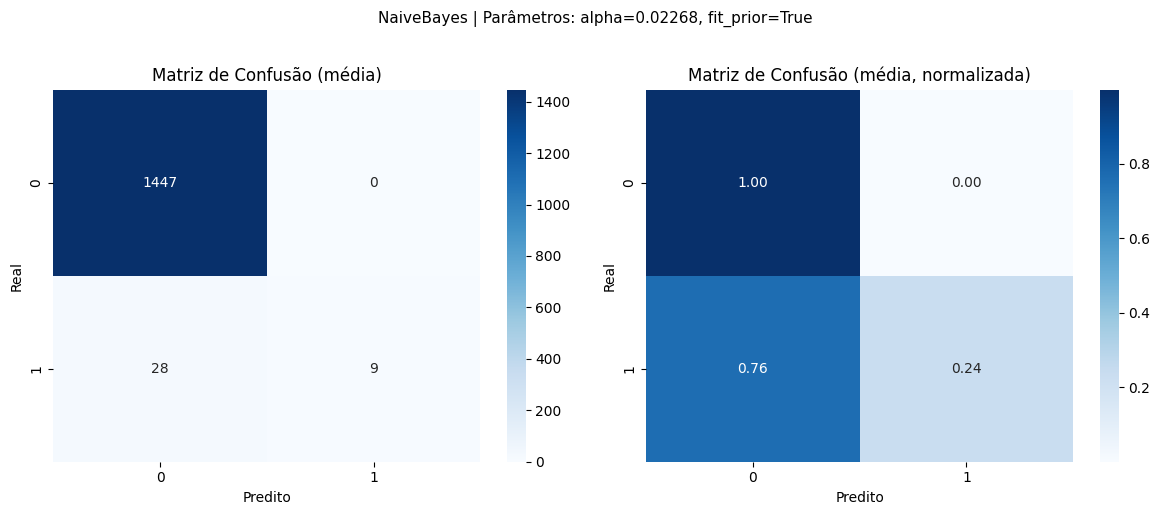

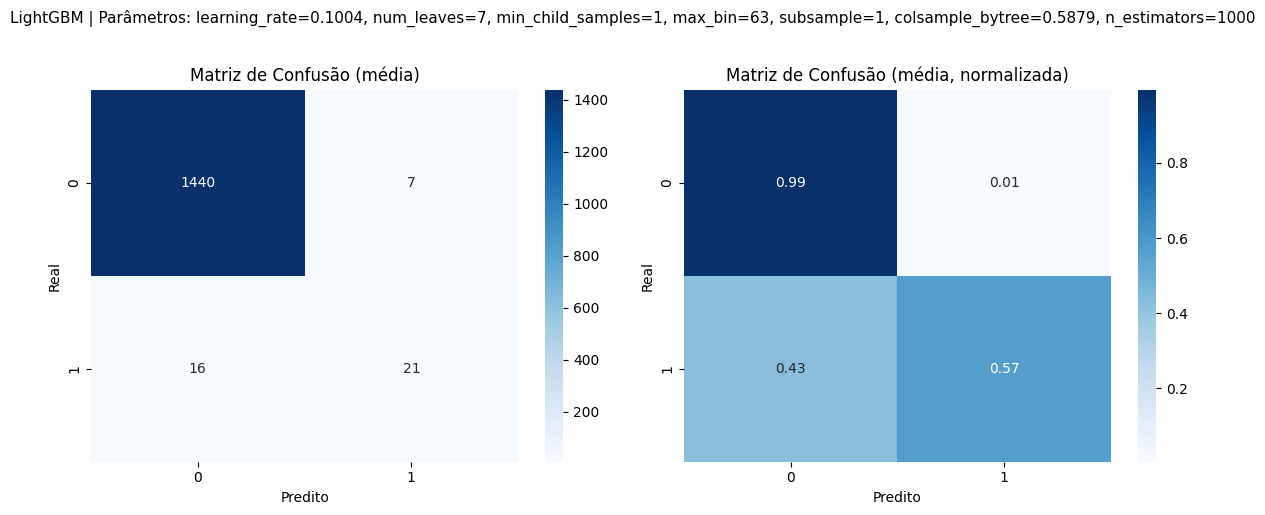

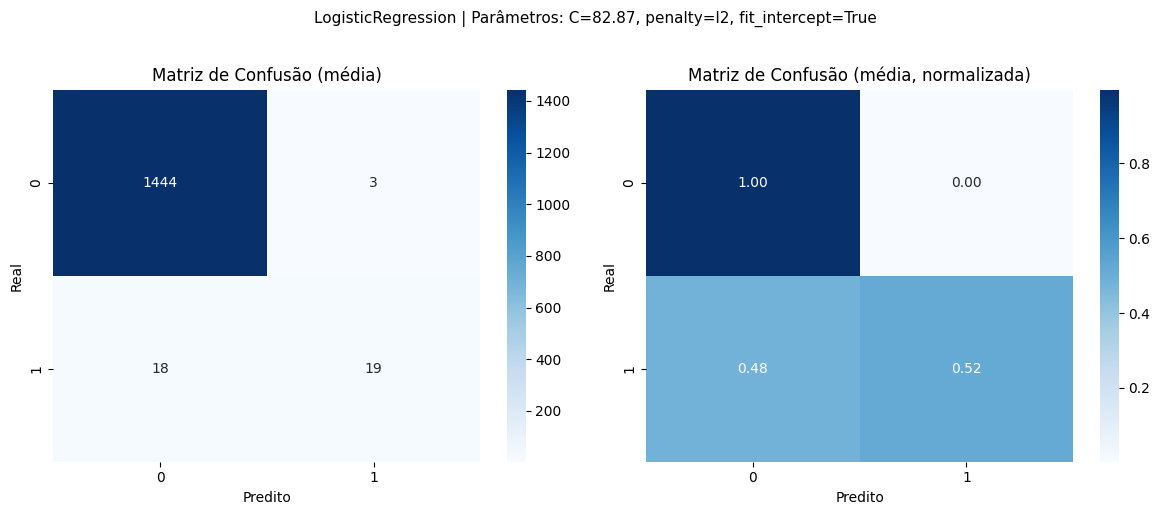

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,GmeanFactor
0,nb,0.98 (0.98-0.98) ± 0.00,0.98 (0.93-0.99) ± 0.03,0.62 (0.60-0.65) ± 0.02,0.68 (0.65-0.72) ± 0.02,0.62 (0.60-0.65) ± 0.02,0.48 (0.44-0.55) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.71 (0.62-0.75) ± 0.05,0.48 (0.43-0.54) ± 0.04
1,lgbm,0.98 (0.98-0.99) ± 0.00,0.86 (0.82-0.90) ± 0.03,0.78 (0.75-0.83) ± 0.03,0.82 (0.79-0.86) ± 0.03,0.78 (0.75-0.83) ± 0.03,0.75 (0.71-0.81) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.70 (0.66-0.76) ± 0.04,0.74 (0.70-0.80) ± 0.04
2,logreg,0.99 (0.98-0.99) ± 0.00,0.92 (0.85-0.97) ± 0.04,0.76 (0.73-0.81) ± 0.03,0.82 (0.78-0.87) ± 0.03,0.76 (0.73-0.81) ± 0.03,0.72 (0.69-0.78) ± 0.04,0.99 (0.98-0.99) ± 0.00,0.76 (0.73-0.80) ± 0.02,0.71 (0.67-0.77) ± 0.04


In [10]:
best_params_by_model = {
    "nb":     results["nb"]["best_params"],
    "lgbm":   results["lgbm"]["best_params"],
    "logreg": results["logreg"]["best_params"],
}


metrics_df, metrics_summary = cv_with_best_params(
    df_train_val, text_col="text", label_col="label", fold_col="fold",
    best_params_by_model=best_params_by_model
)
# metrics_summary["lgbm"] -> DataFrame com métricas por fold para o LGBM, etc.


plot_mean_confusions(df_train_val, "text", "label", "fold", best_params_by_model)
tabela_formatada = format_cv_table(metrics_summary, decimals=2)
tabela_formatada

# Avaliação no Treino com parametros e hiperparâmetros otimizados AUPRC
### Salvamento de modelos
### Avaliação no conjunto de teste

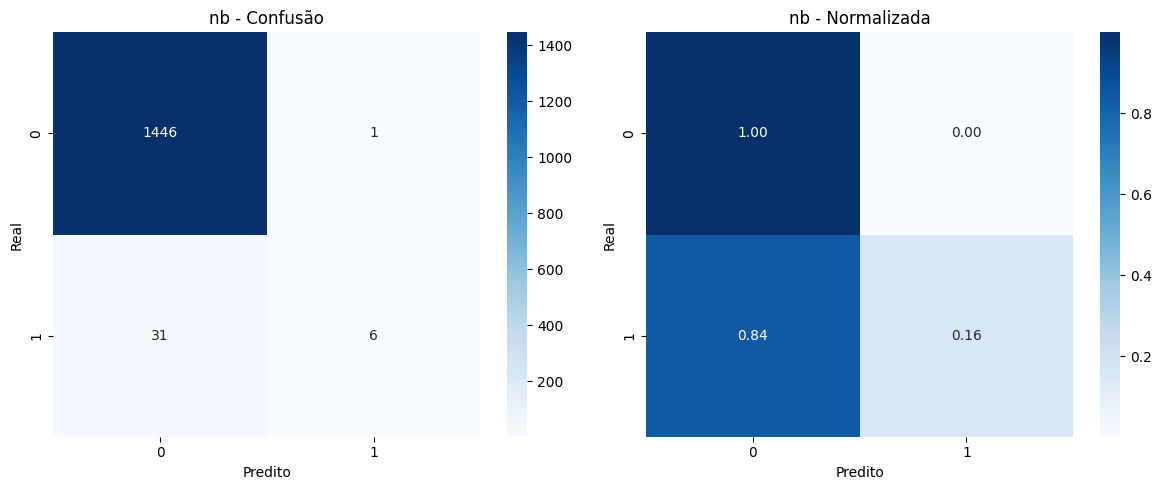

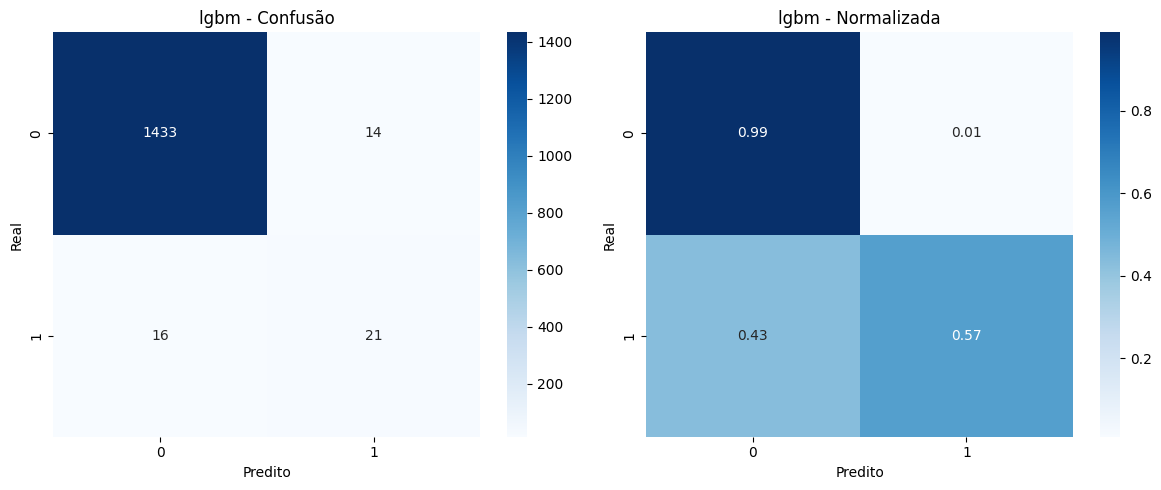

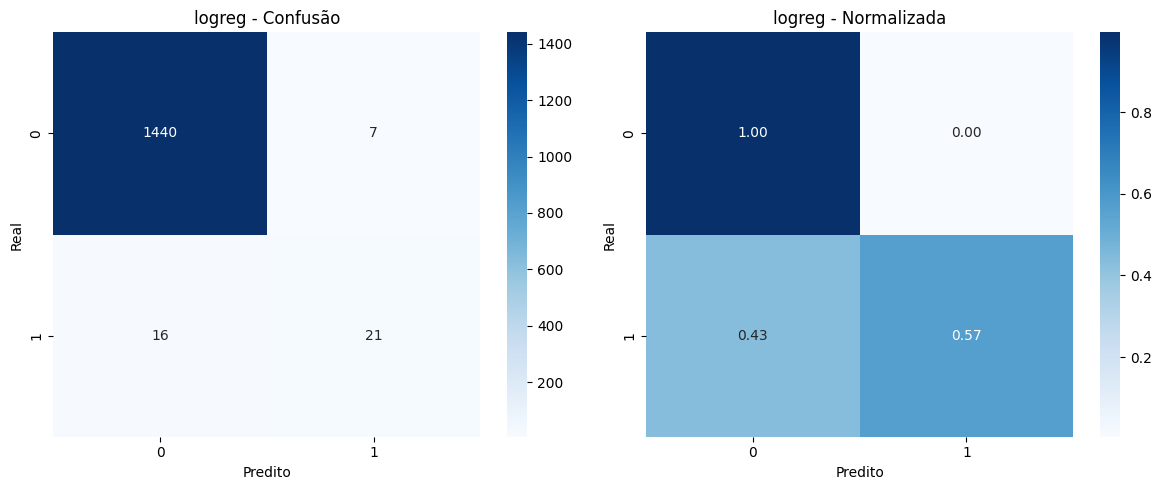

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,GmeanFactor
0,nb,0.978,0.918,0.581,0.631,0.581,0.403,0.978,0.661,0.394
1,lgbm,0.980,0.794,0.779,0.786,0.779,0.750,0.980,0.605,0.735
2,logreg,0.985,0.870,0.781,0.819,0.781,0.752,0.985,0.666,0.740


In [11]:
save_dir = '../models/opt_auprc/'

rows = []
for model_key, best_params in best_params_by_model.items():
    # treino
    pipe = train_with_best_params(df_train_val, "text", "label", model_key, best_params)

    # salvar (opcional)
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        save_model(pipe, os.path.join(save_dir, f"{model_key}_final.joblib"))

    # avaliação (memória)
    m_test, cm, cmn = evaluate_model(pipe, df_test, "text", "label")
    rows.append({"Modelo": model_key, **m_test})

    # plot das matrizes lado a lado
    labels_sorted = np.sort(df_test["label"].unique())
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
    axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real"); axes[0].set_title(f"{model_key} - Confusão")

    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
    axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Real"); axes[1].set_title(f"{model_key} - Normalizada")

    plt.tight_layout()
    plt.show()

metrics_test_df = pd.DataFrame(rows).round(3)
metrics_test_df


# Save Metric Results

In [12]:
out_dir = "../results/opt_auprc"
os.makedirs(out_dir, exist_ok=True)

metrics_test_df.to_csv(os.path.join(out_dir, "test_final.csv"), index=False)
tabela_formatada.to_csv(os.path.join(out_dir, "cv_final.csv"), index=False)

# Otimização de threshold para métrica específica.
- A métrica otimizada não depende de threshold. Conforme a AUPRC se aproxima de 1, o modelo tende a perfeição. 
- Gostaria de otimizar mais ainda essa métrica antes de partir para o curioso experimento a seguir, contudo o trabalho aqui desenvolvido precisa ser entregue. 
- A seguir, otimizamos o threshold utilizando **somente os dados de treino** e aplicamos no teste, para comparação.
    - As métricas escolhidas para otimização foram a Precision (average=Macro) que possui relação intrinseca com a AUPRC e a Acurácia Balanceada
        - Essa abordagem pode ser útil em cenários reais, onde muitas vezes a necessidade de negócio prioriza uma métrica, mesmo que em detrimento da outra.

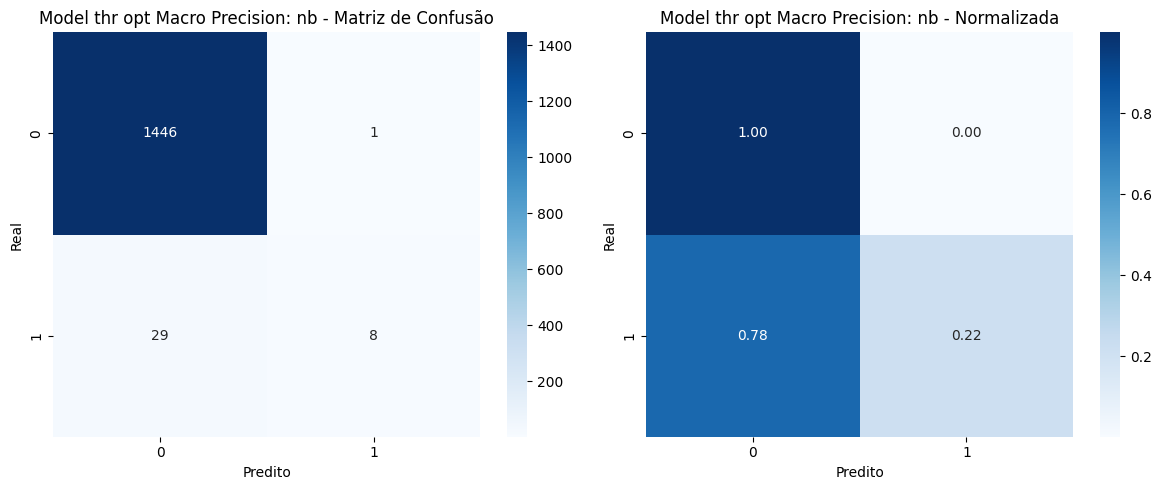

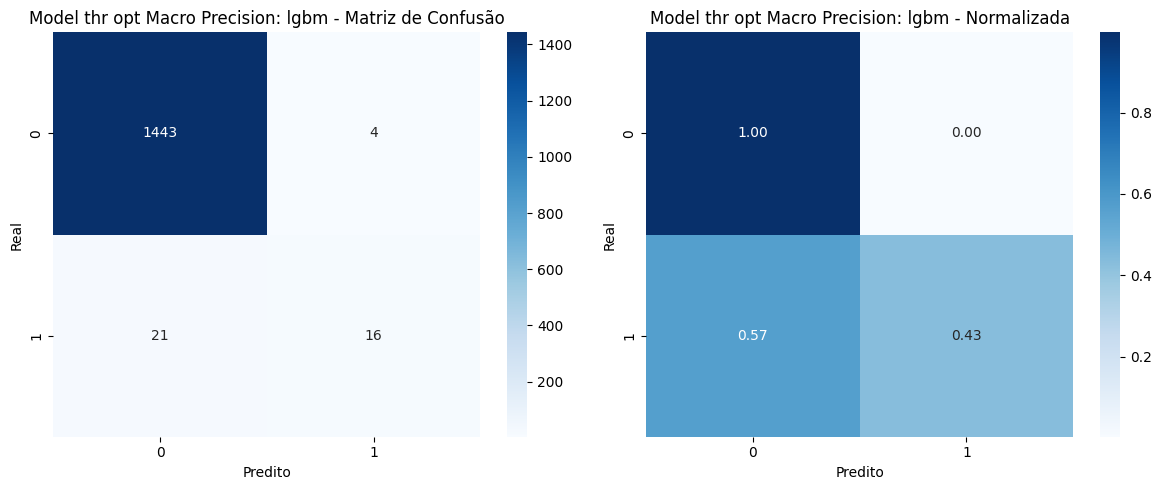

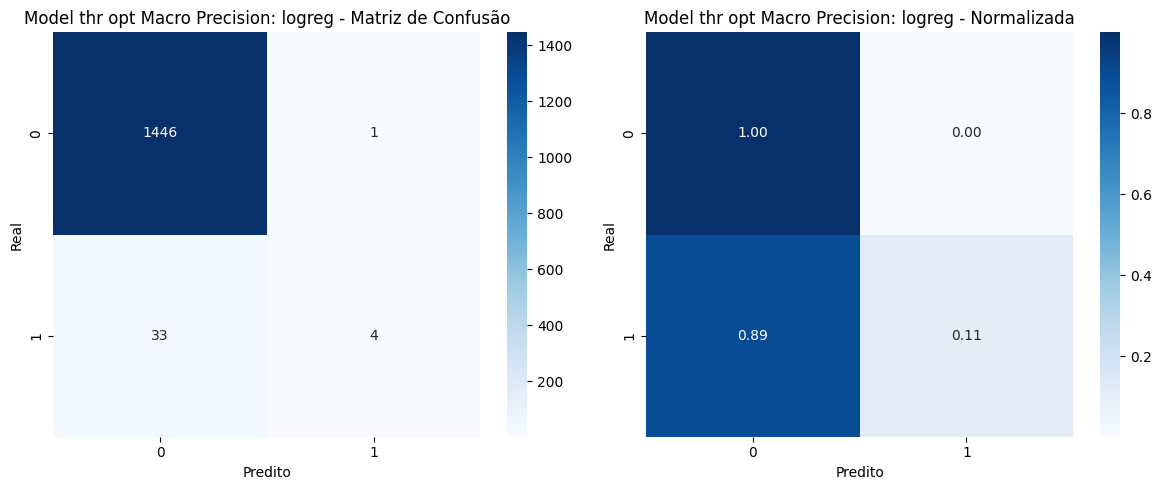

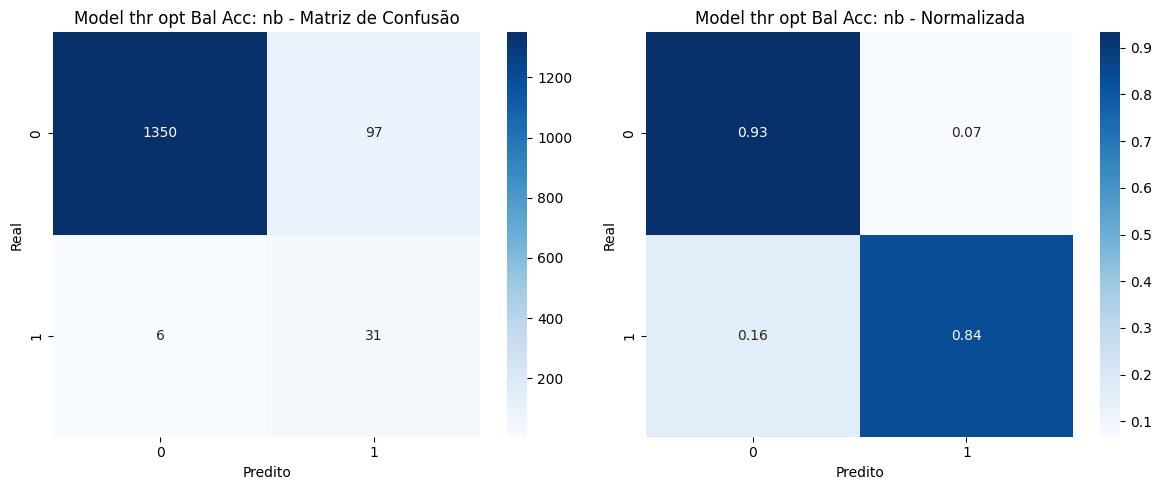

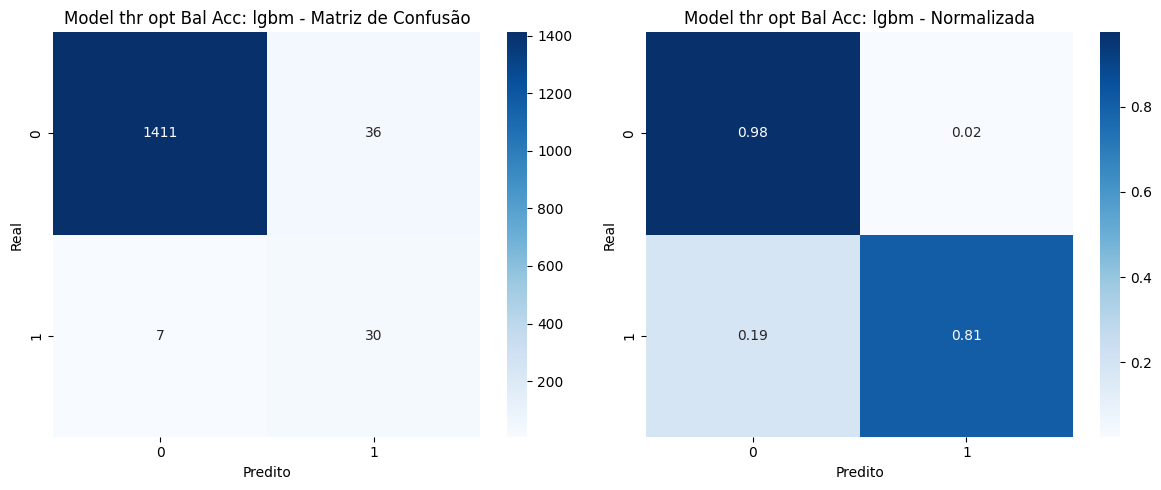

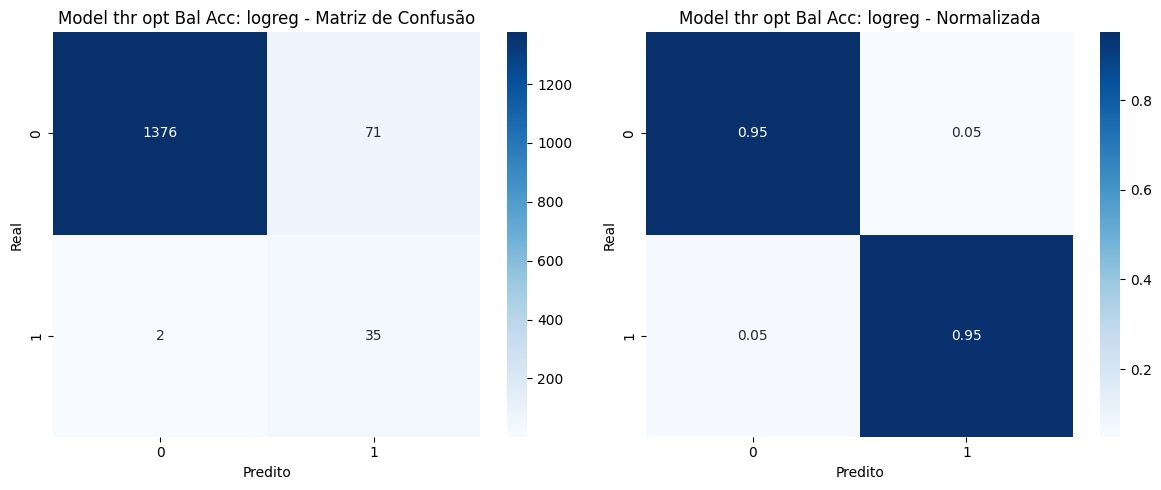

AThresholds salvos em ../results/opt_auprc


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,GmeanFactor
0,nb_auprc,0.978,0.918,0.581,0.631,0.581,0.403,0.978,0.661,0.394
1,lgbm_auprc,0.980,0.794,0.779,0.786,0.779,0.750,0.980,0.605,0.735
2,logreg_auprc,0.985,0.870,0.781,0.819,0.781,0.752,0.985,0.666,0.740
0,nb_thr_opt_precision,0.980,0.935,0.608,0.669,0.608,0.465,0.980,0.661,0.455
0,lgbm_thr_opt_precision,0.983,0.893,0.715,0.776,0.715,0.657,0.983,0.605,0.646
0,logreg_thr_opt_precision,0.977,0.889,0.554,0.589,0.554,0.329,0.977,0.666,0.321
0,nb_thr_opt_bal_acc,0.931,0.619,0.885,0.670,0.885,0.884,0.931,0.661,0.823
0,lgbm_thr_opt_bal_acc,0.971,0.725,0.893,0.784,0.893,0.889,0.971,0.605,0.863
0,logreg_thr_opt_bal_acc,0.951,0.664,0.948,0.732,0.948,0.948,0.951,0.666,0.902


In [13]:
result_test = metrics_test_df.copy()
result_test['Modelo'] = ['nb_auprc','lgbm_auprc','logreg_auprc']

opt_thr_precision = {}
for model_name, best_params in best_params_by_model.items():
    patial_precision = partial(precision_score, average="macro", zero_division=0)
    opt_thr = get_opt_cv_thr(df_train_val, 'fold', 'text', 'label', model_name, best_params, get_pipeline, patial_precision)

    opt_thr_precision[model_name] = opt_thr.copy()
    fitted_pipe = get_pipeline(
        model_name, 
        best_params_by_model[model_name]
        ).fit(df_train_val['text'], df_train_val['label'])

    metrics, cm, cmn = evaluate_model(fitted_pipe, 
                df_test, 'text', 'label', 
                thr=opt_thr['threshold'])
    metrics['Modelo'] = model_name + '_thr_opt_precision'
    result_test = pd.concat([result_test, pd.DataFrame([metrics]).round(3)])
    plot_confusion_matrices(cm, cmn, model_name=f"Model thr opt Macro Precision: {model_name}")

opt_thr_bal_acc = {}
for model_name, best_params in best_params_by_model.items():
    opt_thr = get_opt_cv_thr(df_train_val, 'fold', 'text', 'label', model_name, best_params, get_pipeline, balanced_accuracy_score)
    opt_thr_bal_acc[model_name] = opt_thr.copy()

    fitted_pipe = get_pipeline(
        model_name, 
        best_params_by_model[model_name]
        ).fit(df_train_val['text'], df_train_val['label'])

    metrics, cm, cmn = evaluate_model(fitted_pipe, 
                df_test, 'text', 'label', 
                thr=opt_thr['threshold'])
    metrics['Modelo'] = model_name + '_thr_opt_bal_acc'
    result_test = pd.concat([result_test, pd.DataFrame([metrics]).round(3)])
    plot_confusion_matrices(cm, cmn, model_name=f"Model thr opt Bal Acc: {model_name}")

# salvar thresholds ótimos
with open(os.path.join(out_dir, "opt_thr_precision.json"), "w") as f:
    json.dump(opt_thr_precision, f, indent=4, default=str)

with open(os.path.join(out_dir, "opt_thr_bal_acc.json"), "w") as f:
    json.dump(opt_thr_bal_acc, f, indent=4, default=str)

print("AThresholds salvos em", out_dir)

result_test

# Resultados agregados
## CV

In [14]:
# Baseline and CHI
chi_train = pd.read_csv('../results/chi/cv_chi.csv')
baseline_cond = chi_train['k'] == 'baseline'
base_train = chi_train[baseline_cond].drop(columns=['k'])
cond_used = chi_train['k']=='10000.0'
chi_train = chi_train[cond_used].drop(columns=['k'])
base_train.loc[:, 'Modelo'] = ['nb_base', 'logreg_base', 'lgbm_base']
chi_train.loc[:, 'Modelo'] = ['nb_chi_10k', 'logreg_chi_10k', 'lgbm_chi_10k']

# Pure CHI 10k & Rus 20
rus_train = pd.read_csv('../results/rus_after/cv_rus_after.csv')
cond_F = rus_train['RUS_X'] == '20.0'
rus_train = rus_train[cond_F].drop(columns=['RUS_X'])
rus_train.loc[:, 'Modelo'] = ['nb_chi_10k_rus_20', 'logreg_chi_10k_rus_20', 'lgbm_chi_10k_rus_20']
previous_results = pd.concat([base_train, chi_train, rus_train], ignore_index=True).sort_values('Modelo')

# Union of results
actual_results = tabela_formatada.copy().drop(columns=['GmeanFactor'])
actual_results['Modelo'] = ['nb_auprc','lgbm_auprc','logreg_auprc']
train_results_agg = pd.concat([actual_results, previous_results], ignore_index=True).sort_values('Modelo')


# Save
dir_save = '../results/geral'
os.makedirs(dir_save, exist_ok=True)
train_results_agg.to_csv(f"{dir_save}/cv_final_all.csv", index=False)

# show
train_results_agg

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
1,lgbm_auprc,0.98 (0.98-0.99) ± 0.00,0.86 (0.82-0.90) ± 0.03,0.78 (0.75-0.83) ± 0.03,0.82 (0.79-0.86) ± 0.03,0.78 (0.75-0.83) ± 0.03,0.75 (0.71-0.81) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.70 (0.66-0.76) ± 0.04
3,lgbm_base,0.98 (0.98-0.98) ± 0.00,0.90 (0.83-0.95) ± 0.04,0.69 (0.67-0.73) ± 0.03,0.76 (0.73-0.79) ± 0.03,0.69 (0.67-0.73) ± 0.03,0.62 (0.58-0.69) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.63 (0.59-0.65) ± 0.03
4,lgbm_chi_10k,0.98 (0.98-0.98) ± 0.00,0.88 (0.85-0.91) ± 0.03,0.69 (0.64-0.71) ± 0.03,0.75 (0.70-0.77) ± 0.03,0.69 (0.64-0.71) ± 0.03,0.61 (0.53-0.64) ± 0.05,0.98 (0.98-0.98) ± 0.00,0.64 (0.61-0.66) ± 0.02
5,lgbm_chi_10k_rus_20,0.98 (0.98-0.98) ± 0.00,0.84 (0.80-0.87) ± 0.03,0.74 (0.70-0.78) ± 0.03,0.78 (0.74-0.81) ± 0.03,0.74 (0.70-0.78) ± 0.03,0.69 (0.63-0.74) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.64 (0.57-0.69) ± 0.04
2,logreg_auprc,0.99 (0.98-0.99) ± 0.00,0.92 (0.85-0.97) ± 0.04,0.76 (0.73-0.81) ± 0.03,0.82 (0.78-0.87) ± 0.03,0.76 (0.73-0.81) ± 0.03,0.72 (0.69-0.78) ± 0.04,0.99 (0.98-0.99) ± 0.00,0.76 (0.73-0.80) ± 0.02
6,logreg_base,0.99 (0.98-0.99) ± 0.00,0.86 (0.83-0.89) ± 0.02,0.83 (0.80-0.88) ± 0.03,0.84 (0.82-0.88) ± 0.03,0.83 (0.80-0.88) ± 0.03,0.82 (0.78-0.87) ± 0.04,0.99 (0.98-0.99) ± 0.00,0.73 (0.68-0.79) ± 0.05
7,logreg_chi_10k,0.98 (0.98-0.99) ± 0.00,0.84 (0.82-0.88) ± 0.03,0.83 (0.79-0.86) ± 0.03,0.83 (0.81-0.87) ± 0.02,0.83 (0.79-0.86) ± 0.03,0.81 (0.77-0.85) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.73 (0.67-0.78) ± 0.05
8,logreg_chi_10k_rus_20,0.98 (0.98-0.98) ± 0.00,0.81 (0.79-0.83) ± 0.02,0.84 (0.82-0.86) ± 0.02,0.82 (0.81-0.84) ± 0.01,0.84 (0.82-0.86) ± 0.02,0.83 (0.80-0.85) ± 0.03,0.98 (0.98-0.98) ± 0.00,0.72 (0.66-0.78) ± 0.06
0,nb_auprc,0.98 (0.98-0.98) ± 0.00,0.98 (0.93-0.99) ± 0.03,0.62 (0.60-0.65) ± 0.02,0.68 (0.65-0.72) ± 0.02,0.62 (0.60-0.65) ± 0.02,0.48 (0.44-0.55) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.71 (0.62-0.75) ± 0.05
9,nb_base,0.96 (0.95-0.97) ± 0.01,0.68 (0.65-0.70) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.74 (0.70-0.77) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.89 (0.84-0.94) ± 0.04,0.96 (0.95-0.97) ± 0.01,0.73 (0.68-0.81) ± 0.05


## Conjunto de teste

In [15]:
# Baseline and CHI
chi_test = pd.read_csv('../results/chi/test_chi.csv')
baseline_cond = chi_test['k'] == 'baseline'
base_test = chi_test[baseline_cond].drop(columns=['k', 'Chi2_K'])
cond_used = chi_test['k']=='10000.0'
chi_test = chi_test[cond_used].drop(columns=['k', 'Chi2_K'])
base_test.loc[:, 'Modelo'] = ['nb_base', 'logreg_base', 'lgbm_base']
chi_test.loc[:, 'Modelo'] = ['nb_chi_10k', 'logreg_chi_10k', 'lgbm_chi_10k']
# Pure CHI 10k & Rus 20
rus_test = pd.read_csv('../results/rus_after/test_rus_after.csv')
cond_F = rus_test['RUS_X'] == '20.0'
rus_test = rus_test[cond_F].drop(columns=['RUS_X', 'X', 'Chi2_K'])
rus_test.loc[:, 'Modelo'] = ['nb_chi_10k_rus_20', 'logreg_chi_10k_rus_20', 'lgbm_chi_10k_rus_20']
previous_results = pd.concat([base_test, chi_test, rus_test], ignore_index=True).sort_values('Modelo')

actual_results = result_test.copy().drop(columns=['GmeanFactor'])
test_results_agg = pd.concat([actual_results, previous_results], ignore_index=True).sort_values('Modelo')

# Save
test_results_agg.to_csv(f"{dir_save}/test_final_all.csv", index=False)

# Show
test_results_agg

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
1,lgbm_auprc,0.980,0.794,0.779,0.786,0.779,0.750,0.980,0.605
9,lgbm_base,0.980,0.890,0.700,0.760,0.700,0.640,0.980,0.610
10,lgbm_chi_10k,0.982,0.867,0.701,0.759,0.701,0.636,0.982,0.580
11,lgbm_chi_10k_rus_20,0.980,0.810,0.753,0.779,0.753,0.714,0.980,0.592
7,lgbm_thr_opt_bal_acc,0.971,0.725,0.893,0.784,0.893,0.889,0.971,0.605
4,lgbm_thr_opt_precision,0.983,0.893,0.715,0.776,0.715,0.657,0.983,0.605
2,logreg_auprc,0.985,0.870,0.781,0.819,0.781,0.752,0.985,0.666
12,logreg_base,0.990,0.870,0.820,0.840,0.820,0.800,0.990,0.640
13,logreg_chi_10k,0.987,0.875,0.835,0.854,0.835,0.820,0.987,0.636
14,logreg_chi_10k_rus_20,0.983,0.821,0.847,0.833,0.847,0.834,0.983,0.621
